In [ ]:
# !pip install -qU langchain langchain-nebius langgraph python-dotenv

In [1]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from langchain.tools import tool
from langchain.messages import AnyMessage, SystemMessage, ToolMessage, HumanMessage
from typing_extensions import TypedDict, Annotated
from typing import Literal
import operator
from langgraph.graph import StateGraph, START, END

load_dotenv()

model = ChatNebius(model="MiniMaxAI/MiniMax-M2.5")

@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add a and b."""
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b

tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

def llm_call(state: dict):
    return {
        "messages": [
            model_with_tools.invoke(
                [SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")]
                + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1
    }

def tool_node(state: dict):
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return END

agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()

messages = [HumanMessage(content="Add 3 and 4.")]
result = agent.invoke({"messages": messages})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (chatcmpl-tool-87810447d6262528)
 Call ID: chatcmpl-tool-87810447d6262528
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================



3 + 4 = 7


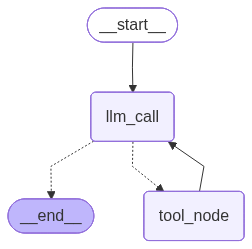

In [ ]:
from IPython.display import Image, display, Markdown
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
from IPython.display import Image, display, Markdown
messages = [HumanMessage(content="Multiply 3 and 4, then add 5 to the result, then divide by 2.")]
result = agent.invoke({"messages": messages})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 3 and 4, then add 5 to the result, then divide by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-bc3aa1eaf51e3da9)
 Call ID: chatcmpl-tool-bc3aa1eaf51e3da9
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

12
================================== Ai Message ==================================
Tool Calls:
  add (chatcmpl-tool-adbcbf5d9960acb7)
 Call ID: chatcmpl-tool-adbcbf5d9960acb7
  Args:
    a: 12
    b: 5
================================= Tool Message =================================

17
================================== Ai Message ==================================
Tool Calls:
  divide (chatcmpl-tool-abf844fa7af99c92)
 Call ID: chatcmpl-tool-abf844fa7af99c92
  Args:
    a: 17
    b: 2
================================= Tool Message ================================

In [ ]:
from IPython.display import display, Markdown

messages = [HumanMessage(content="Multiply 3 and 4, then add 5 to the result, then divide by 2.")]
result = agent.invoke({"messages": messages})

for m in result["messages"]:
    msg_type = type(m).__name__

    if msg_type == "HumanMessage":
        role = "Human"
        content = m.content

    elif msg_type == "AIMessage":
        role = "AI"
        if m.content:
            content = m.content
        elif m.tool_calls:
            calls = "\n".join(
                f"- Tool: {tc['name']}  \n  Args: {tc['args']}"
                for tc in m.tool_calls
            )
            content = f"Calling tools:\n{calls}"
        else:
            content = "_No content_"

    elif msg_type == "ToolMessage":
        role = "Tool"
        content = f"Result: {m.content}"

    elif msg_type == "SystemMessage":
        role = "System"
        content = m.content

    else:
        role = f"{msg_type}"
        content = str(m.content)

    print(content)

Multiply 3 and 4, then add 5 to the result, then divide by 2.
Calling tools:
- Tool: `multiply`  
  Args: `{'a': 3, 'b': 4}`
Result: `12`
Calling tools:
- Tool: `add`  
  Args: `{'a': 12, 'b': 5}`
Result: `17`
Calling tools:
- Tool: `divide`  
  Args: `{'a': 17, 'b': 2}`
Result: `8.5`


The result of multiplying 3 and 4, adding 5, and then dividing by 2 is **8.5**.


In [19]:
from IPython.display import display, Markdown

def format_message(m):
    msg_type = type(m).__name__

    if msg_type == "HumanMessage":
        role = "Human"
        content = m.content

    elif msg_type == "AIMessage":
        role = "AI"
        if m.content:
            content = m.content
        elif m.tool_calls:
            calls = "\n".join(
                f"- Tool: {tc['name']}  \n  Args: {tc['args']}"
                for tc in m.tool_calls
            )
            content = f"Calling tools:\n{calls}"
        else:
            content = "_No content_"

    elif msg_type == "ToolMessage":
        role = "Tool"
        content = f"Result: {m.content}"

    elif msg_type == "SystemMessage":
        role = "System"
        content = m.content

    else:
        role = msg_type
        content = str(m.content)

    return role, content


def print_messages(messages):
    for m in messages:
        role, content = format_message(m)
        print("─" * 60)
        print(f"### {role}\n{content}")
    print("─" * 60)

In [11]:
messages = [HumanMessage(content="Multiply 10 and 4, then add 6 to the result, then divide by 2.")]
result = agent.invoke({"messages": messages})

print_messages(result["messages"])

### Human
Multiply 10 and 4, then add 6 to the result, then divide by 2.
### AI
Calling tools:
- Tool: multiply  
  Args: {'a': 10, 'b': 4}
### Tool
Result: 40
### AI
Calling tools:
- Tool: add  
  Args: {'a': 40, 'b': 6}
### Tool
Result: 46
### AI
Calling tools:
- Tool: divide  
  Args: {'a': 46, 'b': 2}
### Tool
Result: 23.0
### AI


23.0


In [23]:
# ── imports ────────────────────────────────────────────────────────────────
from IPython.display import display, Markdown


# ── format a single message ────────────────────────────────────────────────
def format_message(m):
    msg_type = type(m).__name__

    if msg_type == "HumanMessage":
        role = "Human"
        if isinstance(m.content, list):
            parts = []
            for block in m.content:
                if block.get("type") == "text":
                    parts.append(f"[text]  {block['text']}")
                elif block.get("type") == "image":
                    parts.append(f"[image] {block.get('url', block.get('source', ''))}")
                else:
                    parts.append(str(block))
            content = "\n".join(parts)
        else:
            content = m.content

    elif msg_type == "AIMessage":
        role = "AI"
        if m.content:
            content = m.content
        elif m.tool_calls:
            calls = "\n".join(
                f"  call {i+1}\n"
                f"    tool : {tc['name']}\n"
                f"    args : {tc['args']}\n"
                f"    id   : {tc['id']}"
                for i, tc in enumerate(m.tool_calls)
            )
            content = f"Tool calls:\n{calls}"
        else:
            content = "No content"

    elif msg_type == "ToolMessage":
        role = "Tool"
        content = f"call id : {m.tool_call_id}\nresult  : {m.content}"

    elif msg_type == "SystemMessage":
        role = "System"
        content = m.content

    else:
        role = msg_type
        content = str(m.content)

    if getattr(m, "name", None):
        content += f"\nname : {m.name}"
    if getattr(m, "id", None):
        content += f"\nid   : {m.id}"

    return role, content


# ── print all messages ─────────────────────────────────────────────────────
def print_messages(messages):
    print("━" * 60)
    print(f"  Message trace  ({len(messages)} messages)")
    print("━" * 60)

    for i, m in enumerate(messages):
        role, content = format_message(m)
        print(f"\n  [{i+1}/{len(messages)}]  {role}")
        print("─" * 60)
        for line in content.splitlines():
            print(f"  {line}")

    print("\n" + "━" * 60)

In [24]:
print_messages(result["messages"])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Message trace  (8 messages)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [1/8]  Human
────────────────────────────────────────────────────────────
  Multiply 10 and 4, then add 6 to the result, then divide by 2.

  [2/8]  AI
────────────────────────────────────────────────────────────
  Tool calls:
    call 1
      tool : multiply
      args : {'a': 10, 'b': 4}
      id   : chatcmpl-tool-a2f4f07d1597e99b
  id   : lc_run--019f1e97-59de-7ce3-8d89-bc4f19270294-0

  [3/8]  Tool
────────────────────────────────────────────────────────────
  call id : chatcmpl-tool-a2f4f07d1597e99b
  result  : 40

  [4/8]  AI
────────────────────────────────────────────────────────────
  Tool calls:
    call 1
      tool : add
      args : {'a': 40, 'b': 6}
      id   : chatcmpl-tool-a9b99c06fba0619c
  id   : lc_run--019f1e97-6ca7-7572-890b-b9c8ebb68a4f-0

  [5/8]  Tool
──────────────────────────────────────────────────────────